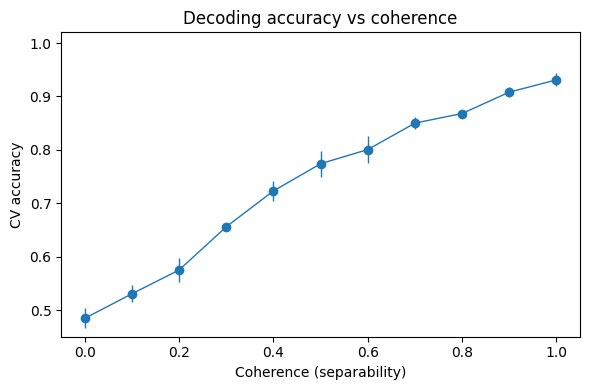

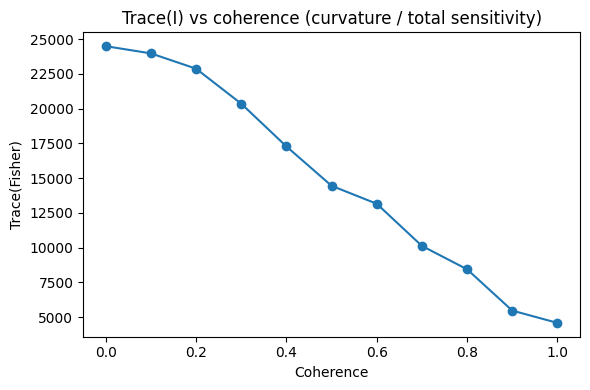

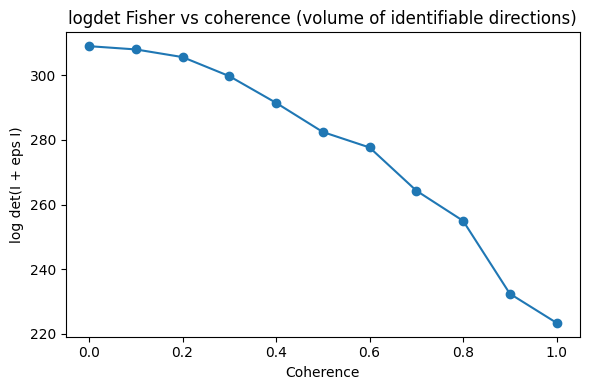

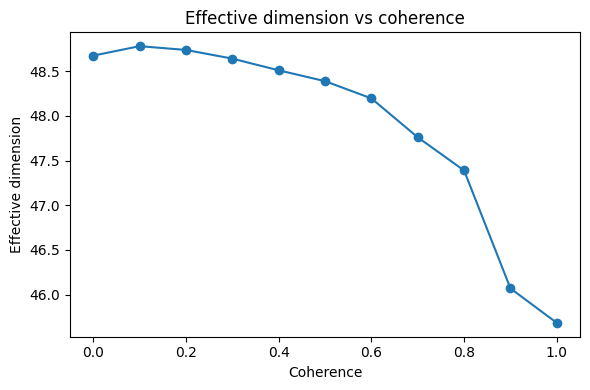

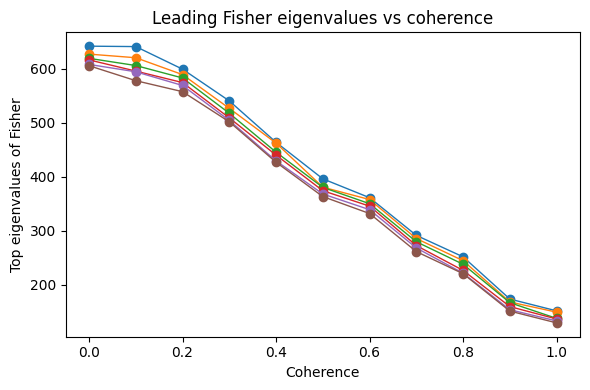

In [1]:
"""
Motion-coherence style simulations for Fisher information in logistic regression.

We simulate two classes with means separated along a "signal" direction.
Coherence c in [0,1] controls separability (confusibility axis), analogous to dot-motion coherence.

For each coherence:
- generate data
- fit logistic regression
- compute Fisher: I = X^T W X, W_ii = p_i (1-p_i)
- record accuracy, trace(I), logdet(I + eps I), effective dimension, top eigenvalues
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# ----------------------------
# Config
# ----------------------------
SEED = 0
rng = np.random.default_rng(SEED)

D = 50                 # feature dimension (think "neurons")
N = 2000               # samples per coherence
coherences = np.linspace(0.0, 1.0, 11)

sigma = 1.0            # noise std
mu_scale = 3.0         # max separation scale (bigger => easier at high coherence)

n_splits = 5
C = 1.0                # inverse reg strength for logistic regression
eps = 1e-8             # for logdet stabilization

# ----------------------------
# Helpers
# ----------------------------
def simulate_dataset(coh, n=N, d=D, sigma=sigma, mu_scale=mu_scale, rng=None):
    """
    Two Gaussians with opposite means along a random unit direction v.
    Separation magnitude grows with coherence: delta = coh * mu_scale.
    """
    if rng is None:
        rng = np.random.default_rng()

    v = rng.normal(size=d)
    v /= np.linalg.norm(v) + 1e-12

    delta = coh * mu_scale
    mu_pos = +0.5 * delta * v
    mu_neg = -0.5 * delta * v

    y = rng.integers(0, 2, size=n)
    X = rng.normal(scale=sigma, size=(n, d))
    X[y == 1] += mu_pos
    X[y == 0] += mu_neg
    return X, y

def fisher_from_fit(X, clf):
    """
    Fisher for fitted logistic regression (fixed design):
    I = X^T W X, W_ii = p_i (1 - p_i)
    """
    p = clf.predict_proba(X)[:, 1]
    w = p * (1.0 - p)
    # Efficient X^T W X without building full diag:
    Xw = X * w[:, None]
    I = X.T @ Xw
    return I, p, w

def effective_dimension(eigs, eps=1e-12):
    """
    Soft effective dimension from eigenvalues:
    d_eff = (trace)^2 / trace(I^2)
    """
    tr = np.sum(eigs)
    tr2 = np.sum(eigs**2) + eps
    return (tr**2) / tr2

# ----------------------------
# Sweep coherences
# ----------------------------
acc_mean = []
acc_std = []
traceI = []
logdetI = []
deff = []
top_eigs = []   # store top-k eigenvalues for plotting
k_top = 10

for coh in coherences:
    X, y = simulate_dataset(coh, rng=rng)

    # Cross-validated accuracy (so we don't fool ourselves)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    accs = []

    # We'll also fit once on full data for Fisher diagnostics
    clf_full = LogisticRegression(
        penalty="l2", C=C, solver="lbfgs", max_iter=2000
    )
    clf_full.fit(X, y)

    for tr_idx, te_idx in skf.split(X, y):
        clf = LogisticRegression(
            penalty="l2", C=C, solver="lbfgs", max_iter=2000
        )
        clf.fit(X[tr_idx], y[tr_idx])
        accs.append(clf.score(X[te_idx], y[te_idx]))

    I, p, w = fisher_from_fit(X, clf_full)

    # Eigen spectrum
    eigs = np.linalg.eigvalsh(I)
    eigs = np.clip(eigs, 0, None)
    eigs_sorted = eigs[::-1]
    top_eigs.append(eigs_sorted[:k_top])

    acc_mean.append(np.mean(accs))
    acc_std.append(np.std(accs))

    tr = np.trace(I)
    traceI.append(tr)

    # logdet(I + eps I)
    # Add eps to avoid logdet issues if I is singular-ish.
    logdet = np.sum(np.log(eigs + eps))
    logdetI.append(logdet)

    deff.append(effective_dimension(eigs))

# Convert
acc_mean = np.array(acc_mean)
acc_std = np.array(acc_std)
traceI = np.array(traceI)
logdetI = np.array(logdetI)
deff = np.array(deff)
top_eigs = np.array(top_eigs)  # shape (n_coh, k_top)

# ----------------------------
# Plots
# ----------------------------
plt.figure(figsize=(6,4))
plt.errorbar(coherences, acc_mean, yerr=acc_std, marker='o', linewidth=1)
plt.xlabel("Coherence (separability)")
plt.ylabel("CV accuracy")
plt.ylim(0.45, 1.02)
plt.title("Decoding accuracy vs coherence")
plt.tight_layout()

plt.figure(figsize=(6,4))
plt.plot(coherences, traceI, marker='o')
plt.xlabel("Coherence")
plt.ylabel("Trace(Fisher)")
plt.title("Trace(I) vs coherence (curvature / total sensitivity)")
plt.tight_layout()

plt.figure(figsize=(6,4))
plt.plot(coherences, logdetI, marker='o')
plt.xlabel("Coherence")
plt.ylabel("log det(I + eps I)")
plt.title("logdet Fisher vs coherence (volume of identifiable directions)")
plt.tight_layout()

plt.figure(figsize=(6,4))
plt.plot(coherences, deff, marker='o')
plt.xlabel("Coherence")
plt.ylabel("Effective dimension")
plt.title("Effective dimension vs coherence")
plt.tight_layout()

plt.figure(figsize=(6,4))
for j in range(min(k_top, 6)):
    plt.plot(coherences, top_eigs[:, j], marker='o', linewidth=1)
plt.xlabel("Coherence")
plt.ylabel("Top eigenvalues of Fisher")
plt.title("Leading Fisher eigenvalues vs coherence")
plt.tight_layout()

plt.show()
